In [1]:
import astra
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import sys 
sys.path.append('..')
import amglib.readers as rd
import amglib.imageutils as amg
import amglib.widgets as aw

from scipy.ndimage import shift

import importlib

import astrautils as au

In [2]:
astra.test()

ASTRA Toolbox v2.3.1
Getting GPU info... GPU #0: Quadro RTX 4000, with 8191MB, CUDA compute capability 7.5
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


## Load and prepare data

In [3]:
path = 'D:/Kaestner/P20250668/02_rawdata/01_Config1/01_Calibration/'
proj0 = rd.read_images(path+'cal_{0:05d}.fits',first=1, last=361)
ob0 = rd.read_images(path+'ob_{0:05d}.fits',first=1, last=5).mean(axis=0)
dc0 = rd.read_images(path+'dc_{0:05d}.fits',first=1, last=5).mean(axis=0)

  0%|          | 0/361 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [4]:
proj = proj0-dc0
proj[proj<1]=1
o = ob0-dc0
o[o<1]=1
proj = proj/o 

In [5]:
N = 4
p_small0 = proj[::N,::N,::N]
p_small = np.transpose(p_small0,(1,0,2))

## Reconstruction

In [8]:
projections = p_small
# Configuration parameters
distance_source_origin   = 395  # Distance from source to origin (object) (mm)
distance_origin_detector = 1327  # Distance from origin (object)  to detector (mm)
detector_pixel_size      = 0.139/N  # Detector pixel size (mm)
detector_rows            = p_small.shape[0]  # Number of detector rows (pixels)
detector_cols            = p_small.shape[2]  # Number of detector columns (pixels)
num_of_projections       = p_small.shape[1]  # Number of projections
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)  # Projection angles

# Divide by magnification
detector_pixel_size_in_origin = detector_pixel_size * distance_source_origin / (distance_source_origin + distance_origin_detector)

proj_geom = astra.create_proj_geom(
    'cone',
    1, 1,
    detector_rows, detector_cols,
    -angles,
    distance_source_origin / detector_pixel_size_in_origin,
    0
)

# Apply the center of rotation correction
proj_geom = astra.geom_postalignment(proj_geom, factor=(0)) #passing the COR offset

# Create ASTRA data object for projections
projections_id = astra.data3d.create('-sino', proj_geom, projections)

# Create ASTRA volume geometry
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)

# Create ASTRA data object for reconstruction
reconstruction_id = astra.data3d.create('-vol', vol_geom, data=0)

# Configure the FDK algorithm
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = projections_id
alg_cfg['ReconstructionDataId'] = reconstruction_id

# Create and run the algorithm
algorithm_id = astra.algorithm.create(alg_cfg)
print("#######running FDK##########")
astra.algorithm.run(algorithm_id)
print("#######finnished FDK##########")

# Retrieve the reconstructed volume
reconstruction = astra.data3d.get(reconstruction_id)

# Post-processing: normalize
reconstruction /= np.max(reconstruction)


#######running FDK##########
#######finnished FDK##########


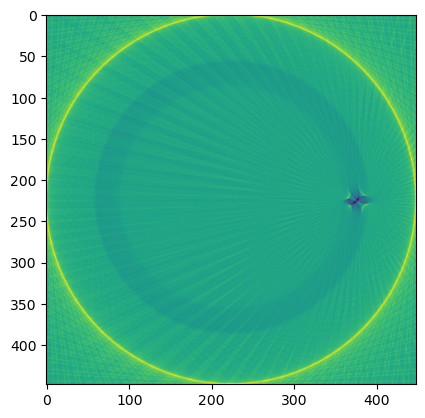

In [9]:
plt.imshow(reconstruction[reconstruction.shape[0]//2])